# 4. データベースとの連携

In [2]:
import os
import sys
from dotenv import load_dotenv
from pathlib import Path
import requests

import plotly.graph_objs as go
import talib as ta
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mplfinance.original_flavor import candlestick_ohlc
import mplfinance as mpf
import matplotlib.dates as mdates
from backtesting import Backtest, Strategy
from Modules.rci import Rci

In [28]:
# APIの接続先（notebookコンテナでは通常 http://api:8000 が設定される）
API_BASE_URL = os.getenv("API_BASE_URL", "http://localhost:8000")
# データを取得する関数
sys.path.append("/workspace/notebook")
from Modules.get_market_data import GetMarketData
get_market_data = GetMarketData(Path('/workspace/data'))

### Yahoo Financeからデータを取得し永続化

In [8]:
# 直近2年の期間を作成
end_date = dt.date.today()
start_date = end_date - dt.timedelta(days=365 * 2)

# Vestas Wind Systems (Yahoo Finance: VWS.CO)
code = "VWS"
market = "CO"

post_payload = {
    "code": code,
    "market": market,
    "name": "Vestas Wind Systems",
    "start": start_date.isoformat(),
    "end": end_date.isoformat(),
}

post_url = f"{API_BASE_URL}/api/v1/stock/data"
post_response = requests.post(post_url, json=post_payload, timeout=60)

print("POST URL:", post_url)
print("POST status:", post_response.status_code)
print("POST response:", post_response.json())

POST URL: http://api:8000/api/v1/stock/data
POST status: 200
POST response: {'result': True}


### GET Requestで株価の時系列データを取得

In [38]:
get_url = f"{API_BASE_URL}/api/v1/stock/get"
get_params = {
    "code": code,
    "market": market,
    "start": start_date.isoformat(),
    "end": end_date.isoformat(),
}

get_response = requests.get(get_url, params=get_params, timeout=60)

print("GET URL:", get_url)
print("GET status:", get_response.status_code)

if get_response.status_code == 200:
    get_json = get_response.json()
    results = get_json.get("results", [])
    df_results = pd.DataFrame(results)

    print("取得件数:", len(df_results))
    display(df_results.head())
else:
    print("GET response:", get_response.json())

GET URL: http://api:8000/api/v1/stock/get
GET status: 200
取得件数: 248


,code,market,date,open,high,low,close,volume
0,VWS,CO,2025-04-01,94.947853,96.259672,92.503101,95.504380,3441746
1,VWS,CO,2025-04-02,95.186363,96.279544,93.258385,94.729215,1627146
2,VWS,CO,2025-04-03,97.134216,97.134216,91.489420,92.125453,3522579
3,VWS,CO,2025-04-04,86.281898,96.935458,85.765125,96.279545,5026384
4,VWS,CO,2025-04-07,85.625992,89.879464,80.637101,80.974998,5456553


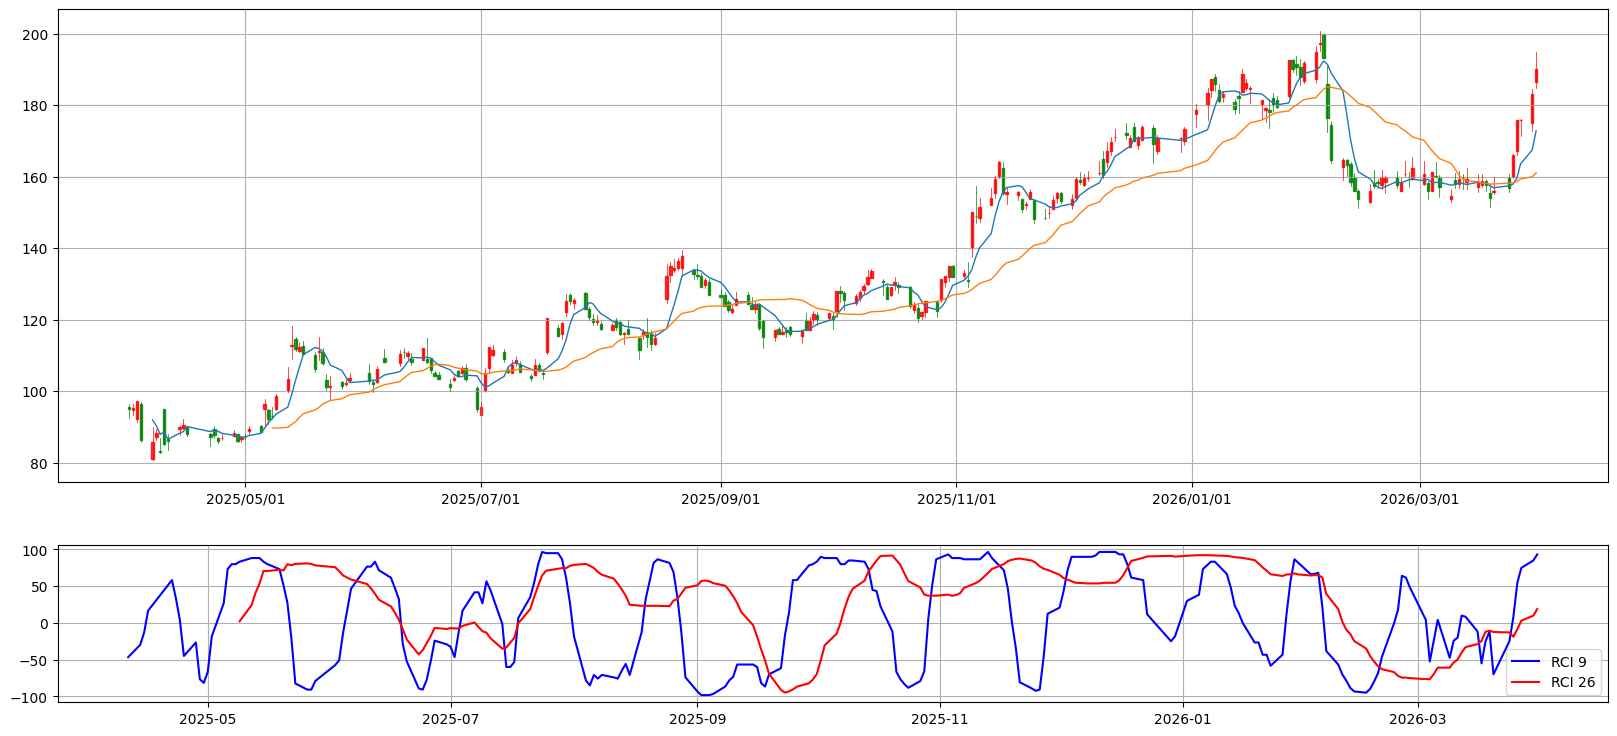

In [39]:
df = df_results.copy()
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)

# データを取得する関数
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()
df = df[df.index.weekday < 5]  # weekdayが0(月曜)〜4(金曜)のみを残す

# 表示開始日
start_date = dt.datetime(2025, 4, 1)
# 表示終了日(現在の日付を取得)
end_date = dt.datetime(2026, 3, 31)

close = df['close']
df['ma5'] = ta.SMA(close ,timeperiod=5)
df['ma25'] = ta.SMA(close ,timeperiod=25)

rci = Rci()
df['RCI9'] = rci.RCI(close.to_list(), timeperiod=9)
df['RCI26'] = rci.RCI(close.to_list(), timeperiod=26)

# インデックスをDatetimeIndexに変換してから範囲でフィルタリング
df.index = pd.to_datetime(df.index)
df = df[start_date:end_date]

# データを準備（matplotlib用）
df['date'] = mdates.date2num(df.index)
ohlc_data = df[['date', 'open', 'high', 'low', 'close']]

# FigureとAxesを作成
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(20, 9), gridspec_kw={'height_ratios': [3, 1]})

# ローソク足チャートを描画
candlestick_ohlc(ax1, ohlc_data.values, width=0.6, colorup='g', colordown='r', alpha=0.8)

ax1.plot(df['date'], df['ma5'], linewidth=1, label='ma5')

ax1.plot(df['date'], df['ma25'], linewidth=1, label='ma25')

# RCIのプロット
ax2.plot(df.index, df['RCI9'], color='blue', label='RCI 9')
ax2.plot(df.index, df['RCI26'], color='red', label='RCI 26')
ax2.legend()

# X軸の日付フォーマットをyyyy/mm/ddに設定
ax1.xaxis_date()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y/%m/%d'))

# 表示
ax1.grid()
ax2.legend()
ax2.grid()
plt.show()

In [40]:
df.head()

,code,market,open,high,low,close,volume,ma5,ma25,RCI9,RCI26,date
date,,,,,,,,,,,,
2025-04-01,VWS,CO,94.947853,96.259672,92.503101,95.504380,3441746,NaN,NaN,NaN,NaN,20179.0
2025-04-02,VWS,CO,95.186363,96.279544,93.258385,94.729215,1627146,NaN,NaN,NaN,NaN,20180.0
2025-04-03,VWS,CO,97.134216,97.134216,91.489420,92.125453,3522579,NaN,NaN,NaN,NaN,20181.0
2025-04-04,VWS,CO,86.281898,96.935458,85.765125,96.279545,5026384,NaN,NaN,NaN,NaN,20182.0
2025-04-07,VWS,CO,85.625992,89.879464,80.637101,80.974998,5456553,91.922718,NaN,NaN,NaN,20185.0
